# 03 — Expected Credit Loss (ECL) Calculation

## Recap: ECL = PD × LGD × EAD

Notebook 02 built the **PD** (Probability of Default) component — a
trained model saved at `models/pd_model.pkl` that estimates, for any
applicant, how likely they are to default.

This notebook builds the other two components and combines all three:

$$ECL = PD \times LGD \times EAD$$

- **PD** — Probability of Default. *Already built* (notebook 02).
- **LGD** — Loss Given Default: if a borrower defaults, what fraction of
  the exposure does the bank actually lose (after any recoveries /
  collateral)?  *Built in this notebook.*
- **EAD** — Exposure at Default: how much money is actually at risk at
  the point of default. *Built in this notebook.*

We then apply **IFRS 9 staging** (which determines whether a loan gets a
12-month or a lifetime ECL), compute a portfolio-level ECL, and run a
simple stress scenario.

> ## ⚠️ Important context — please read before trusting any number below
>
> This dataset (South German Credit) has **no real recovery data,
> collateral valuations, or repayment/amortization schedules**. It was
> built for credit-scoring research, not loss estimation. So the **LGD
> and EAD used in this notebook are deliberate, clearly-labeled
> assumptions**, chosen to illustrate how the ECL mechanism works
> end-to-end — **they are not empirically fitted values**, and the
> resulting ECL figures should not be read as real loss estimates for
> real lending decisions.
>
> A real bank would fit LGD from years of historical recovery data,
> segmented by collateral type and workout outcome, and would compute EAD
> from actual loan amortization schedules (or credit conversion factors
> for revolving exposures) — not from the original disbursed amount.
>
> We'll repeat this caveat at each relevant step, and summarize all
> simplifications in a **Limitations** section at the end.


## Setup

Same libraries as before, plus `joblib` to load the saved PD model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "credit_clean.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "pd_model.pkl"
RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "ecl_results.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load the cleaned data and the trained PD model

We reuse the exact same feature lists (nominal vs. ordinal) from notebook
02 — the saved model's preprocessing pipeline expects columns in this
form.

**Important distinction from notebook 02:** there, we evaluated the model
only on the 30% *test set*, to honestly measure how well it predicts on
data it hadn't seen. Here, we're doing something different — we're
building a **portfolio-level ECL view**, so we score **all 1,000 rows**.
This isn't a model-accuracy exercise anymore; it's "given our best PD
estimate for every current loan in the book, what's our total expected
loss?" (In a real bank, this same scoring step would run on the live loan
book, not on a fixed historical dataset — we're using all 1,000 rows here
as a stand-in for "the current portfolio.")

One thing worth flagging honestly: 700 of these 1,000 rows were *also*
used to train this exact model (notebook 02's 70% training split). So the
PD estimates for those rows are somewhat optimistic compared to genuinely
out-of-sample predictions — another reason the absolute ECL figures below
are illustrative rather than a precise real-world loss forecast.

In [2]:
df = pd.read_csv(DATA_PATH)
pd_model = joblib.load(MODEL_PATH)

NOMINAL_FEATURES = [
    "status", "credit_history", "purpose", "personal_status_sex",
    "other_debtors", "other_installment_plans", "housing", "job",
    "telephone", "foreign_worker",
]
ORDINAL_FEATURES = [
    "duration", "amount", "savings", "employment_duration",
    "installment_rate", "present_residence", "property", "age",
    "number_credits", "people_liable",
]

X_full = df[NOMINAL_FEATURES + ORDINAL_FEATURES]

# predict_proba returns [P(bad), P(good)] since classes are [0, 1].
# Probability of default = 1 - P(good credit).
proba_good = pd_model.predict_proba(X_full)[:, 1]
df["pd_estimate"] = 1 - proba_good

print(f"Scored {len(df)} applicants.")
df["pd_estimate"].describe()

Scored 1000 applicants.


count    1000.000000
mean        0.436203
std         0.269969
min         0.006386
25%         0.203303
50%         0.396410
75%         0.676792
max         0.972184
Name: pd_estimate, dtype: float64

## Loss Given Default (LGD)

**Reminder: this is an assumption, not a fitted value** (see the warning
above). We construct an illustrative LGD from two columns whose ascending
numeric codes are officially documented (in the UCI codebook) to mean
"more": `property` (higher code = more valuable collateral held) and
`savings` (higher code = more savings/bonds held).

**Step 1 — normalize both to a 0-1 scale**, so they're comparable despite
having different code ranges (`property` is 1-4, `savings` is 1-5):

$$x_{normalized} = \frac{x - \min(x)}{\max(x) - \min(x)}$$

**Step 2 — combine into a single "collateral score"**, weighting property
higher since it's literally about collateral, with savings as a weaker
but still relevant liquidity buffer:

$$collateral\_score = 0.6 \times property_{norm} + 0.4 \times savings_{norm}$$

**Step 3 — convert collateral score into LGD**, on a straight line between
a floor and a ceiling:

$$LGD = 0.75 - (0.75 - 0.30) \times collateral\_score$$

An applicant with the **weakest** collateral score (0) gets **LGD = 75%**
(loses three-quarters of exposure if they default); an applicant with the
**strongest** collateral score (1) gets **LGD = 30%**. These 75%/30%
floor and ceiling numbers are **illustrative**, chosen to be roughly in
the ballpark of typical unsecured-vs-secured retail LGD ranges discussed
in credit risk literature — **not fitted to this dataset's actual
outcomes** (which, again, this dataset doesn't contain the recovery data
to do).

In [3]:
property_norm = (df["property"] - df["property"].min()) / (df["property"].max() - df["property"].min())
savings_norm = (df["savings"] - df["savings"].min()) / (df["savings"].max() - df["savings"].min())

collateral_score = 0.6 * property_norm + 0.4 * savings_norm

LGD_FLOOR = 0.30   # best-collateral applicants
LGD_CEILING = 0.75  # worst-collateral applicants

df["LGD"] = LGD_CEILING - (LGD_CEILING - LGD_FLOOR) * collateral_score

df["LGD"].describe()

count    1000.000000
mean        0.578055
std         0.119348
min         0.300000
25%         0.480000
50%         0.570000
75%         0.660000
max         0.750000
Name: LGD, dtype: float64

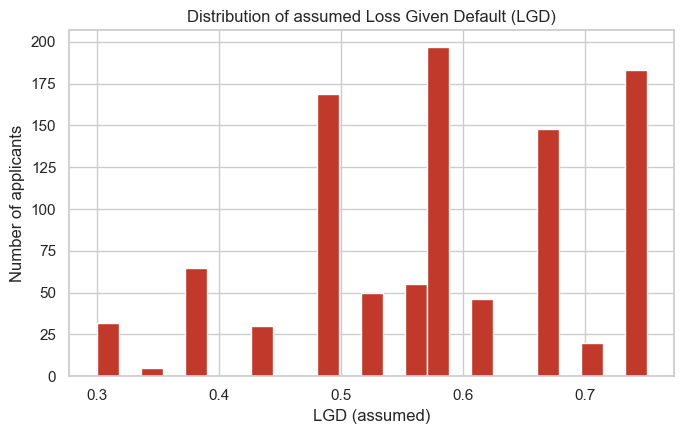

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["LGD"], bins=25, color="#c0392b", edgecolor="white")
ax.set_xlabel("LGD (assumed)")
ax.set_ylabel("Number of applicants")
ax.set_title("Distribution of assumed Loss Given Default (LGD)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ecl_lgd_distribution.png", dpi=150)
plt.show()

## Exposure at Default (EAD)

**Again, this is a simplification** (see the warning above). We use the
`amount` column — the **original disbursed credit amount** — directly as
EAD.

In reality, exposure typically shrinks over the life of an installment
loan as the borrower makes repayments, so EAD at some future default date
is usually *less* than the original amount (unless it's a revolving
facility, or the loan is interest-only). We don't have amortization
schedules or repayment histories in this dataset, so we use the full
original amount as a **simplified, conservative proxy** for exposure — it
will tend to *overstate* true exposure (and therefore ECL) for loans that
have already been partly repaid by the time of default.

In [5]:
df["EAD"] = df["amount"]

df["EAD"].describe()

count     1000.00000
mean      3271.24800
std       2822.75176
min        250.00000
25%       1365.50000
50%       2319.50000
75%       3972.25000
max      18424.00000
Name: EAD, dtype: float64

## IFRS 9 staging

Under IFRS 9, every loan is assigned to one of three **stages**, which
determines *how much* ECL to hold against it:

- **Stage 1** (performing): credit risk hasn't increased significantly
  since origination → hold **12-month ECL** (expected loss from default
  events in the next 12 months only).
- **Stage 2** (significant increase in credit risk / "SICR"): risk has
  risen materially since origination, even though the loan hasn't
  actually defaulted yet → hold **lifetime ECL** (expected loss from
  default events over the loan's full remaining life).
- **Stage 3** (credit-impaired): the loan has actually defaulted / is
  credit-impaired → also **lifetime ECL**.

**The real IFRS 9 test for Stage 2 is a *change over time*** — comparing
an applicant's *current* PD to their PD *at origination*. A loan that was
always risky but hasn't gotten worse stays in Stage 1; a loan that
started safe but has deteriorated moves to Stage 2. **Our dataset is a
single snapshot** — we only observe each applicant once, with no history
of how their risk has evolved — so we **cannot** compute a genuine
origination-vs-current comparison. Instead, we use a **simplified proxy**
based on the *absolute level* of predicted PD, plus the one piece of
real outcome information we do have (whether the loan is a known
historical default):

- **Stage 3**: `credit_risk == 0` — i.e. this applicant is a **known
  historical default** in our data. These get lifetime ECL regardless of
  the model's predicted PD (we already know the outcome).
- **Stage 2**: `pd_estimate >= 0.50` **and** not already Stage 3 —
  treated as "high enough predicted risk to warrant lifetime ECL" as a
  stand-in for "risk has significantly increased."
- **Stage 1**: `pd_estimate < 0.50` **and** not Stage 3 — performing,
  12-month ECL.

This is a reasonable illustrative proxy, but it is **not** how staging
actually works in production IFRS 9 models — flagged again in the
Limitations section below.

In [6]:
def assign_stage(row):
    if row["credit_risk"] == 0:
        return "Stage 3"
    elif row["pd_estimate"] >= 0.50:
        return "Stage 2"
    else:
        return "Stage 1"

df["stage"] = df.apply(assign_stage, axis=1)

stage_counts = df["stage"].value_counts().reindex(["Stage 1", "Stage 2", "Stage 3"])
stage_amount_pct = (
    df.groupby("stage")["amount"].sum().reindex(["Stage 1", "Stage 2", "Stage 3"])
    / df["amount"].sum() * 100
)

staging_summary = pd.DataFrame({
    "n_applicants": stage_counts,
    "pct_of_total_loan_amount": stage_amount_pct.round(1),
})
staging_summary

,n_applicants,pct_of_total_loan_amount
stage,,
Stage 1,528,43.2
Stage 2,172,20.7
Stage 3,300,36.1


## ECL calculation

**Stage 2 (lifetime ECL):**

$$ECL_{lifetime} = PD \times LGD \times EAD$$

**Stage 3 is a special case.** Stage 3 loans are known defaults, so PD is
treated as 100% rather than the model's predicted probability — only LGD
and EAD determine the loss:

$$ECL_{Stage\ 3} = LGD \times EAD$$

**Stage 1 (12-month ECL)** needs a 12-month PD, but our model outputs a
PD without a specified time horizon attached. As a simplification, we
**prorate** the model's PD down to a 12-month view based on how long the
loan actually is:

$$PD_{12m} = PD \times \min\left(1, \frac{12}{duration}\right)$$

$$ECL_{Stage\ 1} = PD_{12m} \times LGD \times EAD$$

**Intuition:** if a loan's full duration is already 12 months or less,
the 12-month view *is* the lifetime view, so the ratio is 1 and nothing
changes. If the loan is longer (say 48 months), we scale the PD down
proportionally (12/48 = 25% of it) under the simplifying assumption that
default risk is spread out roughly evenly across the loan's life. **A
real bank would not do this** — it would use **vintage curves or a
survival/hazard model** fitted on historical default timing data, since
default risk is very rarely uniform across a loan's life (it typically
peaks in the middle years for installment loans, not at a constant
rate). We're using proration here purely because we lack the timing data
a real term-structure model would need.

In [7]:
def compute_ecl(row):
    if row["stage"] == "Stage 3":
        # Known default: PD is certain (100%), so only LGD and EAD matter.
        return row["LGD"] * row["EAD"]
    elif row["stage"] == "Stage 2":
        return row["pd_estimate"] * row["LGD"] * row["EAD"]
    else:
        pd_12m = row["pd_estimate"] * min(1, 12 / row["duration"])
        return pd_12m * row["LGD"] * row["EAD"]

df["ecl"] = df.apply(compute_ecl, axis=1)

total_ecl = df["ecl"].sum()
total_ead = df["EAD"].sum()

print(f"Total portfolio EAD: {total_ead:,.0f} DM")
print(f"Total portfolio ECL: {total_ecl:,.0f} DM")
print(f"ECL as % of portfolio EAD: {total_ecl / total_ead * 100:.1f}%")

Total portfolio EAD: 3,271,248 DM
Total portfolio ECL: 1,028,795 DM
ECL as % of portfolio EAD: 31.4%


## Scenario analysis: base vs. stressed

Banks don't just report ECL under current conditions — IFRS 9 explicitly
requires considering **forward-looking, probability-weighted economic
scenarios** (e.g. a recession scenario where more borrowers default).

We build one simple **illustrative** stress scenario: multiply every
applicant's `pd_estimate` by **1.5**, capped at 1.0 (a probability can't
exceed 100%). This is a rough stand-in for "a macroeconomic downturn
makes every borrower meaningfully riskier" — **it is not a calibrated
economic scenario** (a real bank would derive stressed PDs from a
macroeconomic model linking, e.g., unemployment or GDP projections to
default rates). We then **re-run staging and the ECL calculation** with
these stressed PDs, from scratch — including checking whether any
applicants now cross the Stage 1 → Stage 2 threshold ("migrate") purely
because their stressed PD is higher, even though nothing about the
applicant themselves changed.

In [8]:
df["pd_stressed"] = (df["pd_estimate"] * 1.5).clip(upper=1.0)

def assign_stage_stressed(row):
    if row["credit_risk"] == 0:
        return "Stage 3"
    elif row["pd_stressed"] >= 0.50:
        return "Stage 2"
    else:
        return "Stage 1"

df["stage_stressed"] = df.apply(assign_stage_stressed, axis=1)

def compute_ecl_stressed(row):
    if row["stage_stressed"] == "Stage 3":
        # Known default: PD is certain (100%) regardless of the stress shock.
        return row["LGD"] * row["EAD"]
    elif row["stage_stressed"] == "Stage 2":
        return row["pd_stressed"] * row["LGD"] * row["EAD"]
    else:
        pd_12m = row["pd_stressed"] * min(1, 12 / row["duration"])
        return pd_12m * row["LGD"] * row["EAD"]

df["ecl_stressed"] = df.apply(compute_ecl_stressed, axis=1)

# How many applicants moved from Stage 1 (base) to Stage 2 (stressed) purely
# because of the stress shock?
migrated = df[(df["stage"] == "Stage 1") & (df["stage_stressed"] == "Stage 2")]
print(f"Applicants that migrated Stage 1 -> Stage 2 under stress: {len(migrated)}")

total_ecl_base = df["ecl"].sum()
total_ecl_stressed = df["ecl_stressed"].sum()
increase = total_ecl_stressed - total_ecl_base
pct_increase = increase / total_ecl_base * 100

scenario_table = pd.DataFrame({
    "total_ecl": [total_ecl_base, total_ecl_stressed],
    "increase_vs_base": [0, increase],
    "pct_increase_vs_base": [0.0, round(pct_increase, 1)],
}, index=["Base case", "Stressed case (PD x 1.5, capped at 1.0)"])
scenario_table

Applicants that migrated Stage 1 -> Stage 2 under stress: 138


,total_ecl,increase_vs_base,pct_increase_vs_base
Base case,1.028795e+06,0.000000,0.0
"Stressed case (PD x 1.5, capped at 1.0)",1.239301e+06,210505.956096,20.5


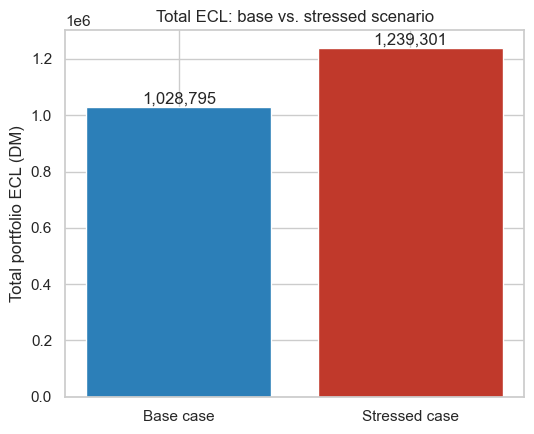

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(["Base case", "Stressed case"],
              [total_ecl_base, total_ecl_stressed],
              color=["#2c7fb8", "#c0392b"])
ax.set_ylabel("Total portfolio ECL (DM)")
ax.set_title("Total ECL: base vs. stressed scenario")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():,.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ecl_base_vs_stressed.png", dpi=150)
plt.show()

## Outputs

### Applicant count and total ECL by stage (base case)

In [10]:
stage_ecl_table = df.groupby("stage").agg(
    n_applicants=("ecl", "size"),
    total_ecl=("ecl", "sum"),
).reindex(["Stage 1", "Stage 2", "Stage 3"])
stage_ecl_table["pct_of_total_ecl"] = (stage_ecl_table["total_ecl"] / stage_ecl_table["total_ecl"].sum() * 100).round(1)
stage_ecl_table

,n_applicants,total_ecl,pct_of_total_ecl
stage,,,
Stage 1,528,118455.793566,11.5
Stage 2,172,260560.699921,25.3
Stage 3,300,649778.145000,63.2


### Top 10 applicants by ECL amount

These are the individual exposures a real risk team would look at first —
the largest single contributors to the portfolio's expected loss, driven
by some combination of high PD, high LGD (weak collateral), and/or large
loan amount.

In [11]:
top10 = df.sort_values("ecl", ascending=False).head(10)[
    ["duration", "amount", "purpose", "age", "pd_estimate", "LGD", "EAD", "stage", "ecl"]
].round(3)
top10

,duration,amount,purpose,age,pd_estimate,LGD,EAD,stage,ecl
976,48,18424,10,32,0.860,0.66,18424,Stage 3,12159.840
810,48,15672,9,23,0.859,0.57,15672,Stage 3,8933.040
645,36,15857,10,43,0.970,0.57,15857,Stage 2,8768.269
929,48,14421,9,25,0.946,0.57,14421,Stage 3,8219.970
962,54,15945,9,58,0.972,0.48,15945,Stage 3,7653.600
218,47,10722,0,35,0.909,0.75,10722,Stage 2,7311.123
977,6,14896,0,68,0.798,0.48,14896,Stage 3,7150.080
754,6,14555,0,23,0.320,0.48,14555,Stage 3,6986.400
782,36,14318,0,57,0.900,0.48,14318,Stage 3,6872.640
844,24,11938,10,39,0.704,0.57,11938,Stage 3,6804.660


### Save full results

We save the original data plus the five new columns we built
(`pd_estimate`, `LGD`, `EAD`, `stage`, `ecl`) to
`data/processed/ecl_results.csv`, so this portfolio-level view can be
reused or reported on without re-running the notebook.

In [12]:
output_columns = list(df.columns[:21]) + ["pd_estimate", "LGD", "EAD", "stage", "ecl"]
df[output_columns].to_csv(RESULTS_PATH, index=False)
print(f"Saved results for {len(df)} applicants to: {RESULTS_PATH}")

Saved results for 1000 applicants to: E:\ecl-credit-risk-model\data\processed\ecl_results.csv


## Summary

*(Numbers below are the actual results from running this notebook
top-to-bottom — see the tables and charts above for the live figures.)*

- **Total base-case portfolio ECL**: **1,028,795 DM** on total exposure
  (EAD) of **3,271,248 DM** — an overall ECL rate of **31.4%** of the
  portfolio. (Stage 3's known-default correction — PD treated as 100%
  instead of the model's prediction — added roughly 197,311 DM to this
  total versus using the model's predicted PD for those loans.)
- **Total stressed-case portfolio ECL**: **1,239,301 DM**, an increase of
  **210,506 DM (20.5%)** over the base case, driven partly by **138
  applicants** migrating from Stage 1 into Stage 2 (12-month → lifetime
  ECL) purely due to the stress shock. (The stress shock only moves PD
  for Stage 1/2 loans — Stage 3's PD is already fixed at 100%, which is
  why the stressed-case % increase is smaller now than before this
  correction: a larger, PD-insensitive share of the portfolio's ECL sits
  in Stage 3.)
- **Portfolio composition by loan amount**: Stage 1 (performing) holds
  **43.2%** of total loan amount, Stage 2 (significant increase in risk)
  **20.7%**, and Stage 3 (credit-impaired / known default) **36.1%**.
  By contrast, **Stage 3 now contributes 63.2%** of total ECL despite
  being only 36.1% of loan amount — a direct consequence of treating its
  PD as certain.

### Business recommendation (as if reporting to a risk committee)

Under the base case, close to a third of this portfolio's total exposure
would need to be provisioned for as expected credit loss — a high figure
that is inflated by this being an illustrative dataset with a 30% known
historical default rate (well above what most real retail loan books
carry) and by the deliberately conservative LGD/EAD assumptions described
above. Known defaults (Stage 3) now account for the clear majority of
total provisioning despite being just over a third of loan amount,
because their loss is certain (PD = 100%) rather than model-estimated —
a reminder that known outcomes should never be diluted by a model's
uncertainty. The stress scenario shows provisioning needs could still
rise by roughly 20% under a moderate PD shock, with over a hundred
currently-performing loans at risk of migrating into higher-provisioning
stages — underscoring why ECL should be monitored under multiple
forward-looking scenarios, not just current conditions. Before these
figures could inform actual capital or provisioning decisions, the LGD
and EAD assumptions would need to be replaced with figures fitted to
this institution's own historical recovery and amortization data, and
staging would need genuine origination-vs-current PD tracking rather
than the absolute-threshold proxy used here.

## Limitations

This notebook demonstrates the **mechanics** of an ECL calculation
end-to-end. It should **not** be read as a production-grade loss
forecast. Specifically:

1. **LGD is assumed, not fitted.** We derived it from `property` and
   `savings` using hand-picked weights and a 30%-75% floor/ceiling range,
   not from historical recovery/workout data (which this dataset doesn't
   contain).
2. **EAD is the full original loan amount, not an amortized balance.**
   Real exposure typically declines over an installment loan's life; we
   don't have repayment schedules to model that, so our EAD likely
   overstates true exposure at any given point in time.
3. **IFRS 9 staging is a simplified PD-threshold proxy**, not a genuine
   origination-vs-current risk comparison. This dataset is a single
   snapshot per applicant, so we can't observe how any individual's risk
   has changed over time, which is what real Stage 2 classification is
   supposed to capture.
4. **The 12-month PD for Stage 1 is a straight-line proration**
   (`PD × 12/duration`), not a term-structure or survival model. Real
   default risk is rarely spread evenly across a loan's life.
5. **The PD model itself saw 70% of these applicants during training**
   (notebook 02's training split), so PD estimates — and therefore ECL —
   are somewhat optimistic relative to a genuinely out-of-sample
   portfolio.
6. **The stress scenario (PD × 1.5) is illustrative**, not derived from
   any macroeconomic model or calibrated economic scenario.
7. **Stage 3 PD is fixed at 100%, not the model's predicted probability**
   (corrected in this version of the notebook). Stage 3 loans are known
   historical defaults, so using the model's predicted PD — which can be
   well below 100% if the model happened to score a known defaulter as
   lower-risk — would have understated their expected loss. Treating
   known outcomes as certain is standard practice; only LGD and EAD
   remain uncertain for these loans.

Every one of these would need to be replaced with real, data-driven
methodology before this pipeline could be used for actual provisioning
decisions.